In [48]:
# Import the required libraries

import numpy as np
import pandas as pd

import yfinance as yf
import datetime
import matplotlib.pyplot as plt

# To use statsmodels for linear regression
import statsmodels.formula.api as smf

# To use sklearn for linear regression
from sklearn.linear_model import LinearRegression

In [49]:
# Fetch data from yfinance
# 3-year daily data for Coca-Cola, SPY, Pepsi, and USD index

end = datetime.date(2021, 7, 28)
start = end - pd.Timedelta(days = 365 * 3)
ticker = ['KO','SPY','PEP','DX-Y.NYB']

df = yf.download(tickers=ticker, start = start, end = end,auto_adjust=True)['Close']
df.columns = ['dx','ko','pep','spy']

# Calcualting log returns
df['dx'] = np.log(df['dx']/df['dx'].shift(1))
df['ko'] = np.log(df['ko']/df['ko'].shift(1))
df['pep'] = np.log(df['pep']/df['pep'].shift(1))
df['spy'] = np.log(df['spy']/df['spy'].shift(1))

# Dropping Nan Values
df.dropna(inplace = True)


[*********************100%***********************]  4 of 4 completed


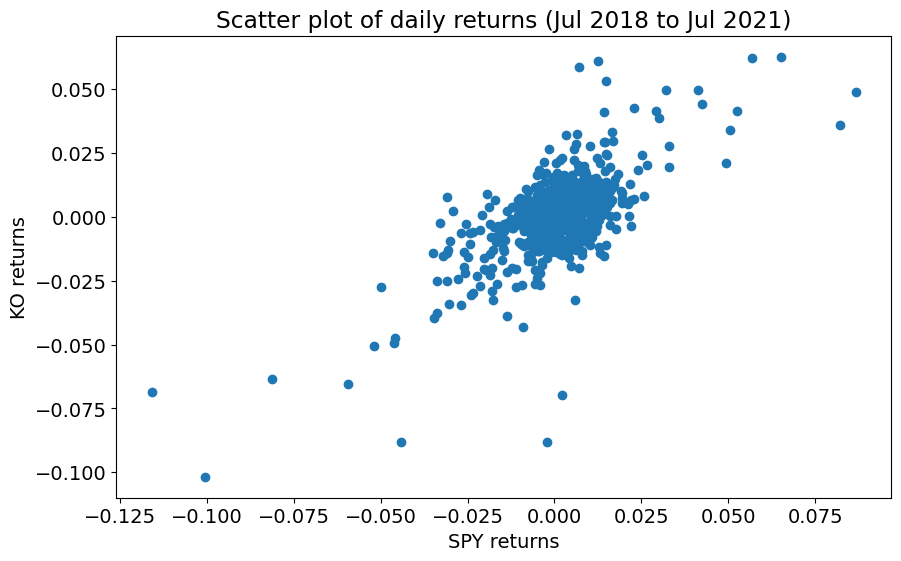

In [50]:
# A scatter plot of X (spy) and Y (ko) to examine the nature of their relationship visually

plt.figure(figsize = (10, 6))
plt.rcParams.update({'font.size': 14})
plt.xlabel("SPY returns")
plt.ylabel("KO returns")
plt.title("Scatter plot of daily returns (Jul 2018 to Jul 2021)")
plt.scatter(df['spy'], df['ko'])
plt.show()

In [27]:
# 1. Calculate correlation between Xs and Y

df.corr()

,spy,ko,pep,usdx
spy,1.000000,0.685607,0.727079,-0.038681
ko,0.685607,1.000000,0.739574,-0.097766
pep,0.727079,0.739574,1.000000,-0.005847
usdx,-0.038681,-0.097766,-0.005847,1.000000


In [28]:
## 2a. Fit a simple linear regression model to the data using statsmodels

### Create an instance of the class OLS
slr_sm_model = smf.ols('ko ~ spy', data=df)

### Fit the model (statsmodels calculates beta_0 and beta_1 here)
slr_sm_model_ko = slr_sm_model.fit()

### Summarize the model

print(slr_sm_model_ko.summary())

param_slr = slr_sm_model_ko.params

                            OLS Regression Results                            
Dep. Variable:                     ko   R-squared:                       0.470
Model:                            OLS   Adj. R-squared:                  0.469
Method:                 Least Squares   F-statistic:                     666.1
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          1.19e-105
Time:                        10:05:16   Log-Likelihood:                 2322.5
No. Observations:                 753   AIC:                            -4641.
Df Residuals:                     751   BIC:                            -4632.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept  -7.541e-05      0.000     -0.186      0.8

In [29]:
### Print the parameter estimates of the simple linear regression model

print("\n")
print("The intercept in the statsmodels regression model is", \
      np.round(param_slr.Intercept, 4))
print("The slope in the statsmodels regression model is", \
      np.round(param_slr.spy, 4))
print("\n")



The intercept in the statsmodels regression model is -0.0001
The slope in the statsmodels regression model is 0.7296




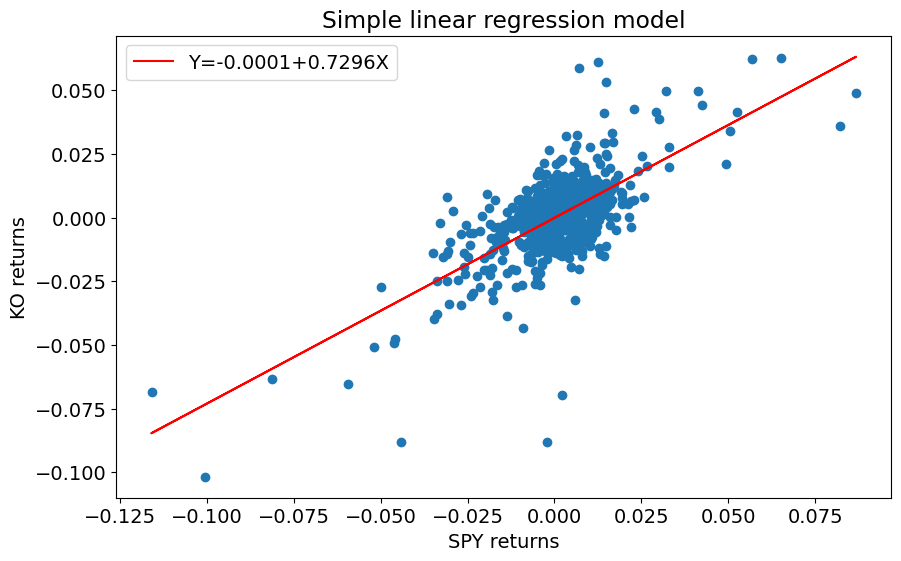

In [30]:
## Linear regression plot of X (spy) and Y (ko)
plt.figure(figsize = (10, 6))
plt.rcParams.update({'font.size': 14})
plt.xlabel("SPY returns")
plt.ylabel("KO returns")
plt.title("Simple linear regression model")
plt.scatter(df['spy'],df['ko'])
plt.plot(df['spy'], param_slr.Intercept+param_slr.spy * df['spy'],
         label='Y={:.4f}+{:.4f}X'.format(param_slr.Intercept, param_slr.spy),
         color='red')
plt.legend()
plt.show()

In [31]:
# Fit a multiple linear regression model to the data using statsmodels
# Create an instance of the class OLS

mlr_sm_model = smf.ols('ko ~ spy + pep + usdx', data=df)

# Fit the model (statsmodels calculates beta_0, beta_1, beta_2, beta_3 here)

mlr_sm_model_ko = mlr_sm_model.fit()

# Summarize the model

print(mlr_sm_model_ko.summary())

                            OLS Regression Results                            
Dep. Variable:                     ko   R-squared:                       0.600
Model:                            OLS   Adj. R-squared:                  0.599
Method:                 Least Squares   F-statistic:                     374.8
Date:                Sat, 21 Mar 2026   Prob (F-statistic):          1.30e-148
Time:                        10:05:17   Log-Likelihood:                 2428.7
No. Observations:                 753   AIC:                            -4849.
Df Residuals:                     749   BIC:                            -4831.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -9.2e-05      0.000     -0.262      0.7

In [32]:
# Print the parameter estimates of the muliple linear regression model

param_mlr = mlr_sm_model_ko.params

print("\n")
print("The intercept and slopes in the statsmodels regression model are")
print("\n")
print(param_mlr)
print("\n")



The intercept and slopes in the statsmodels regression model are


Intercept   -0.000092
spy          0.327410
pep          0.502913
usdx        -0.344075
dtype: float64




In [33]:
# Create an instance of the class LinearRegression()

slr_skl_model = LinearRegression()

# Fit the model (sklearn calculates beta_0 and beta_1 here)

X = df['spy'].values.reshape(-1, 1)
slr_skl_model_ko = slr_skl_model.fit(X, df['ko'])

print("The intercept in the sklearn regression result is", \
      np.round(slr_skl_model_ko.intercept_, 4))
print("The slope in the sklearn regression model is", \
      np.round(slr_skl_model_ko.coef_[0], 4))

The intercept in the sklearn regression result is -0.0001
The slope in the sklearn regression model is 0.7296


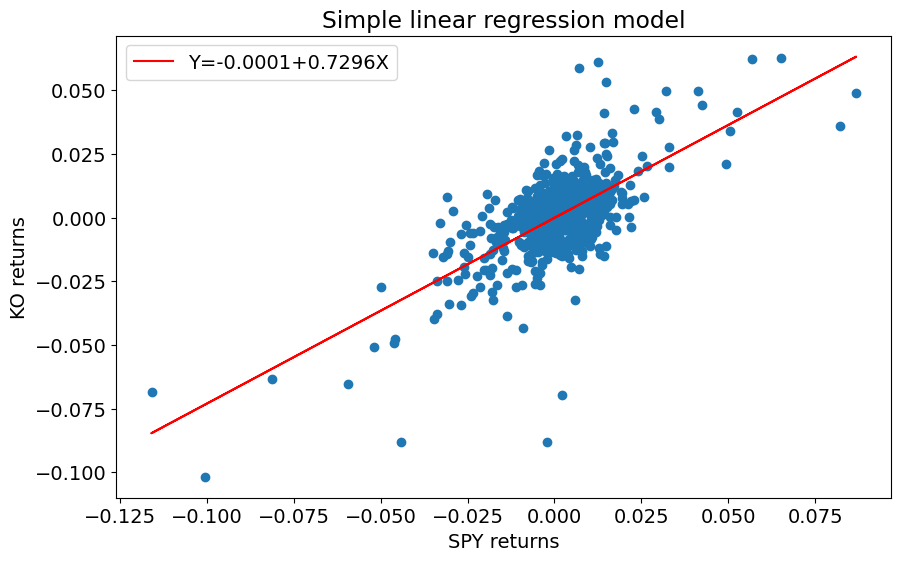

In [34]:
# Linear regression plot of X (spy) and Y (ko)

plt.figure(figsize = (10, 6))
plt.rcParams.update({'font.size': 14})
plt.xlabel("SPY returns")
plt.ylabel("KO returns")
plt.title("Simple linear regression model")
plt.scatter(df['spy'], df['ko'])
plt.plot(X, slr_skl_model.predict(X),
         label='Y={:.4f}+{:.4f}X'.format(slr_skl_model_ko.intercept_, \
                                         slr_skl_model_ko.coef_[0]),
             color='red')
plt.legend()
plt.show()


In [35]:
# Print the parameter estimates of the simple linear regression model

print("\n")
print("The intercept in the sklearn regression result is", \
      np.round(slr_skl_model_ko.intercept_, 4))
print("The slope in the sklearn regression model is", \
      np.round(slr_skl_model_ko.coef_[0], 4))
print("\n")



The intercept in the sklearn regression result is -0.0001
The slope in the sklearn regression model is 0.7296




In [36]:
# Fit a multiple linear regression model to the data using sklearn

# Create an instance of the class LinearRegression()

mlr_skl_model = LinearRegression()

# Fit the model (sklearn calculates beta_0 and beta_1 here)

X = df[['spy', 'pep', 'usdx']]
y = df['ko']
mlr_skl_model_ko = mlr_skl_model.fit(X, y)

In [37]:
print("The intercept in the sklearn regression result is", \
      mlr_skl_model_ko.intercept_)
print("The slope in the sklearn regression model is", \
      mlr_skl_model_ko.coef_)

The intercept in the sklearn regression result is -9.200315367657863e-05
The slope in the sklearn regression model is [ 0.32740983  0.50291328 -0.34407487]
